_Neural Data Science_

Lecturer: Dr. Jan Lause, Prof. Dr. Philipp Berens

Tutors: Jonas Beck, Fabio Seel, Julius Würzler

Summer term 2025

Student names: Maria Elisabeth Dirnberger, Akseli Ilmanen, Caroline Grießhaber

LLM Disclaimer: We used LLMs (ChatGPT) a little, especially for the plotting.

# Coding Lab 8: Neural Morphologies

## Introduction

The anatomical shape of a neuron — its morphology — has fascinated scientists ever since the pioneering work of Cajal (Ramon y Cajal, 1911). A neuron's dendritic and axonal processes naturally decide what other neurons it can connect to, hence, its shape plays an important role for its function in the circuit. In particular, different functional types of neurons have fundamentally different morphologies.

This notebook will introduce you to the analysis of neural morphologies using the dendrites of over $500$ retinal ganglion cells. The aim is to teach you two different ways of representing morphologies and give you an impression of their repsective strengths and weaknesses.

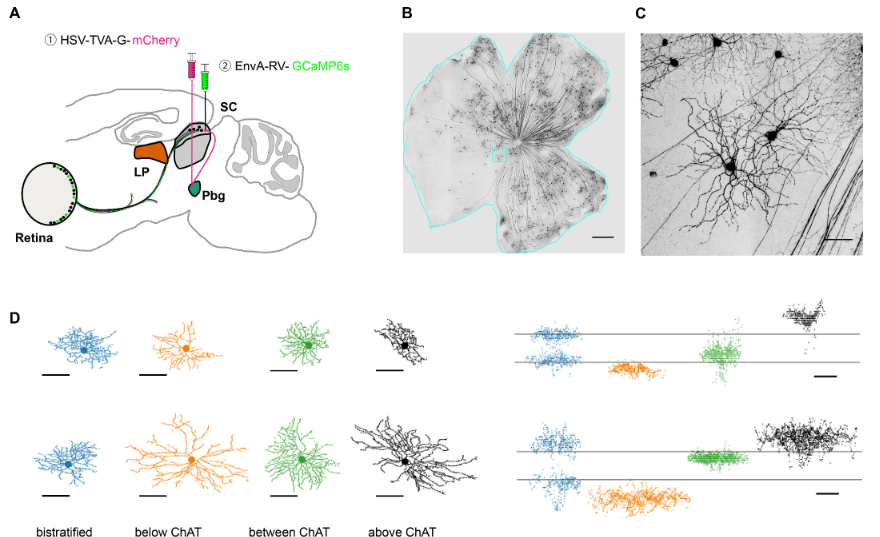

### 1. Data

The data set contains morphological reconstructions of $599$ retinal ganglion cell dendrites with cell type label and projection target to either the parabigeminal (Pbg) or the pulvinar nucleus (LP)([Reinhard et al. (2019)](https://elifesciences.org/articles/50697)). 
Here we only keep cells that map to clusters with more than six cells per cluster which leads to $550$ remaining reconstructions. 

Download the data file `nds_cl_8.zip` from ILIAS and unzip it in a subfolder `../data/`


### 2. Toolbox

We will use MorphoPy (Laturnus, et al., 2020; https://github.com/berenslab/MorphoPy) for this exercise. We recommend to use the Github version, as it is more up-to-date:

```
git clone https://github.com/berenslab/MorphoPy
pip install -e MorphoPy
```

Most of the computations and even some plottings will be handled by MorphoPy. You can learn more about MorphoPy's APIs in this [tutorial](https://nbviewer.jupyter.org/github/berenslab/MorphoPy/blob/master/notebooks/MORPHOPY%20Tutorial.ipynb). 

In [60]:
import pandas as pd
import numpy as np
import os

from morphopy.computation import file_manager
from morphopy.neurontree.plotting import show_threeview
from morphopy.neurontree import NeuronTree as nt

import warnings

warnings.filterwarnings("ignore")

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

%load_ext jupyter_black

%load_ext watermark
%watermark --time --date --timezone --updated --python --iversions --watermark -p sklearnv

The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black
The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Last updated: 2025-06-19 11:06:14Mitteleuropäische Sommerzeit

Python implementation: CPython
Python version       : 3.12.4
IPython version      : 8.25.0

sklearnv: not installed

numpy     : 2.0.0
matplotlib: 3.9.2
seaborn   : 0.13.2
morphopy  : 0.7.2
re        : 2.2.1
pandas    : 2.2.2
openTSNE  : 1.0.2

Watermark: 2.5.0



In [61]:
plt.style.use("../matplotlib_style.txt")

# Inspect the raw data

#### File format

Morphological reconstructions are typically stored in the SWC file format, a simple text file that holds node information in each row and connects nodes through the `parent` node id. A parent id of -1 indicates no parent, so the starting point of the tree graph, also called the root. 
The `type` label indicates the node type (1: somatic , 2: axonal, 3: dendritic (basal), 4: dendritic (apical), 5+: custom).
The code snippet below loads in one swc file and prints its head. 

You can find a more detailed specification of SWC and SWC+ [here](http://www.neuronland.org/NLMorphologyConverter/MorphologyFormats/SWC/Spec.html) and [here](https://neuroinformatics.nl/swcPlus/).



In [62]:
def load_swc(filepath: str) -> pd.DataFrame:
    """Loads in the swc located at filepath as a pandas dataframe.

    Args:
        filepath (str): The path to the swc file.

    Returns:
        pd.DataFrame: A pandas dataframe containing the swc file.
    """
    swc = pd.read_csv(
        filepath,
        delim_whitespace=True,
        comment="#",
        names=["n", "type", "x", "y", "z", "radius", "parent"],
        index_col=False,
    )
    return swc


# define color for each cluster
colors = sns.color_palette("rainbow_r", n_colors=14)

In [63]:
# import swc file
PATH = "../data/nds_cl_8/"
data_path = PATH + "reconstructions/soma-centered/"
filename = "0006_00535_4L_C02_01.swc"
filepath = data_path + filename

swc = load_swc(filepath)
swc.head()

,n,type,x,y,z,radius,parent
0,1,1,0.00,0.00,0.47,1.0,-1
1,2,3,-0.03,0.00,0.47,1.0,1
2,3,3,0.17,-0.08,0.51,1.0,1
3,4,3,0.24,-0.31,0.38,1.0,3
4,5,3,0.02,0.14,0.42,1.0,1


The labels `x`, `y`, and `z` hold a node's 3D coordinate in tracing space (here in microns). For reasons of simplicity we will work with reconstructions that are soma centered in XY.

The assigned cell type labels are stored in the file `rgc_labels.csv` and indexed by their `Cell_nr`. In this file you find three different cluster assignments: `clusterA` is the assignment of the authors (clus1 -- clus14), `clusterB` is the respective cluster identifier of the [Eyewire museum](http://museum.eyewire.org) (also see [Bae et al. 2018](https://www.sciencedirect.com/science/article/pii/S0092867418305725)), and `clusterC` are molecular or functional label names when available. 
We have formatted the cluster assignments of the authors (`clusterA`) into integer values and stored them in the column `cluster`, which we will use in the following.

In [64]:
labels = pd.read_csv(PATH + "rgc_labels.csv", index_col=0)

cluster_label, cluster_counts = np.unique(labels["cluster"], return_counts=True)
labels.head()

,Cell_nr,projection_site,clusterA,clusterB,clusterC,cluster
1,2,LP,clus6,4ow,tOFFα,6
2,3,LP,clus2,2an,F-mini-OFF,2
3,4,LP,clus1,1wt,sOFFα,1
4,6,LP,clus7,5to,NaN,7
5,7,LP,clus10,6sn,NaN,10


**Note:** for team: The `cell_nur` in `rgc_labels.csv`, corresponds to the prefix in `.swc` files. E.g. the last file `0763_00925_2L_C04_01.swc`, has `cell_nur=763`.

## Task 1: Plotting individual morphologies

Load data using `file_manager` and plot individual morphologie using `show_threeview` of from `MorphoPy`. It plots all three planar views on the reconstruction. 

Here, XY shows the planar view on top of the retina, and Z denotes the location within the inner plexiform layer (IPL).

Noted, by default, the `file_manager` loads data with `pca_rot=True` and `soma_center=True`. For the all the exercise in this Coding Lab, it's better to set both of them as `False`. 

*Grading: 2pts*

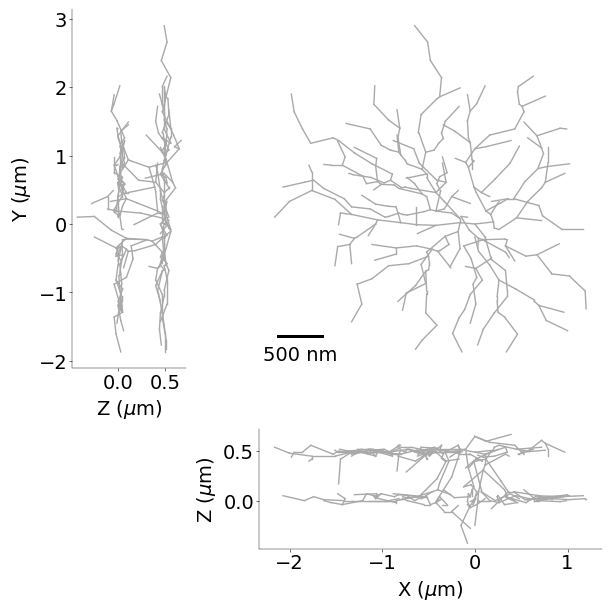

In [65]:
# ----------------------------------------------------------------
# load the example cell "0060_00556_3R_C02_01" with `file_manager`
# from morphology (0.5 pts)
filename = "0060_00556_3R_C02_01.swc"
filepath = data_path + filename
N = file_manager.load_swc_file(filepath, pca_rot=False, soma_center=False)

# ----------------------------------------------------------------

# -------------------------------------
# plot all three planar views (0.5 pts),

fig = plt.figure(figsize=(6, 6))
show_threeview(N, fig)

# -------------------------------------

### Questions (0.5 pts)

1) Describe the dendritic structure of this neuron. How is it special? Can you even give a technical term for its appearance?

**Answer:**

Given the cue that this cell is in the IPL and that it's dendrites are spread very far arcross the XY plane, I assume this is an amacrine cell. What's noteworthy is that the dendrites are spread across two distinct planes/layers in the Z-plane. In the context of amacrine cells this is referred to as "bistratified" or "bilaminar".


SWC files are a compact way for storing neural morphologies but their graph structure makes them difficult to handle for current machine learning methods. We, therefore, need to convert our reconstructions into a reasonable vector-like representations. 

Here we will present two commonly chosen representations: Morphometric statistics and density maps


In [66]:
# load all reconstructions. Note: files are sorted by cell number
def load_files(path: str) -> list[nt]:
    """Returns list of NeuronTrees for all .swc files in `path`.
    The reconstructions should be sorted ascendingly by their filename.

    Args:
        path (str): The path to the folder containing the reconstructions.

    Returns:
        list[nt]: An object array of NeuronTrees containing all reconstructions at `path`.
    """
    neurons = []
    # ----------------------------------------------------------
    # use `file_manager` to import all reconstructions (0.5 pts)
    # Note the list should be sorted by filename.
    # ----------------------------------------------------------

    # get all the files in path
    files = os.listdir(path)
    files.sort()

    for filename in files:
        if filename.endswith(".swc"):
            filepath = os.path.join(path, filename)
            neuron = file_manager.load_swc_file(
                filepath, pca_rot=False, soma_center=False
            )
            neurons.append(neuron)  # list of objects

    return neurons, files


neurons, files = load_files(data_path)
print("Number of reconstructions: ", len(neurons))

Number of reconstructions:  550


## Task 2: Morphometric statistics

Morphometric statistics denote a set of hand-crafted single valued features such as `soma radius`, `number of tips` or `average branch angle`. For a more detailed explanation of morphometrics please refer to the [MorphoPy documentation](https://github.com/berenslab/MorphoPy#morphometric-statistics).

*Grading: 4pts*

First, let's compute the feature-based representation for each cell using the function `compute_morphometric_statistics` of the MorphoPy package which computes a predefined set of $28$ statistics.


**Note:** for team: The `cell_nur` in `rgc_labels.csv`, corresponds to the prefix in `.swc` files. E.g. the last file `0763_00925_2L_C04_01.swc`, has `cell_nur=763`.

In [67]:
from morphopy.computation.feature_presentation import compute_morphometric_statistics
import re


# --------------------------------------------------------------------------
# 1. extraction the morphometric statistics for the entire data set (0.5 pts)

mylist = []
for i, neuron in enumerate(neurons):
    stats = compute_morphometric_statistics(neuron)
    mylist.append(stats)
temp1 = pd.concat(mylist, ignore_index=True)
# -----------------------------------------------------------------------------------


# -----------------------------------------------------------------------------------
# 2. concatenate data into one pd.DataFrame and set the `Cell_nr`` as index (0.5 pts)
temp2 = pd.DataFrame()
temp2["Cell_nr"] = [int(re.match(r"(\d{4})", f).group(1)) for f in files]
temp2["cluster"] = labels["cluster"]

morphometric_statistics = pd.concat([temp2, temp1], axis=1)

# -----------------------------------------------------------------------------------

Now let's visualize the data.

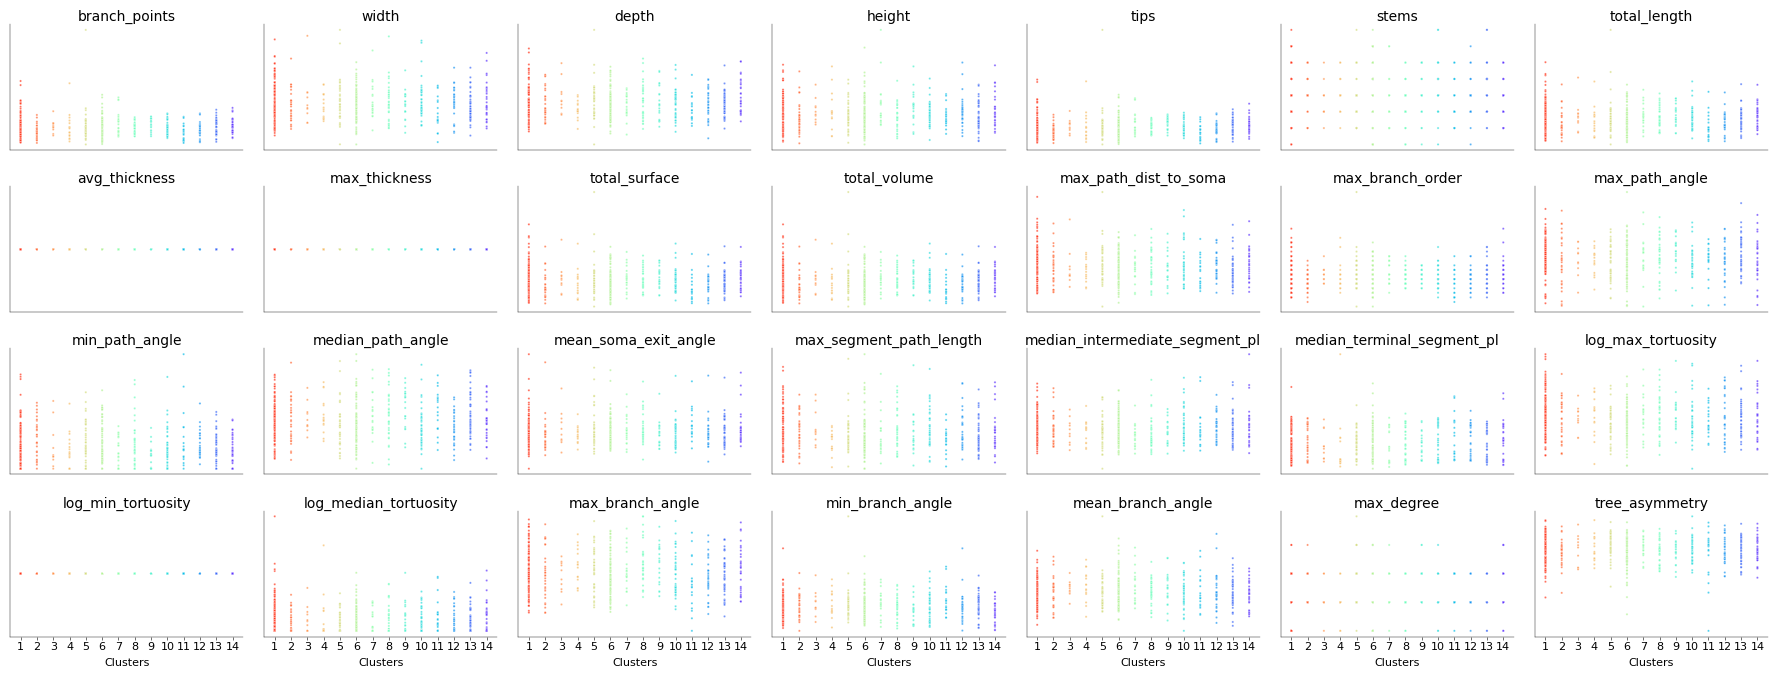

In [68]:
features = morphometric_statistics.columns.values

fig, axes = plt.subplots(4, 7, figsize=(18, 7))
axes = axes.flatten()

# -----------------------------------------------------------
# Create a scatter/strip plot for each morphometric statistic
# showing how it varies across clusters. (2 pts)

# first two column in features are cell_nr and cluster
for i, feature in enumerate(features[2:]):
    ax = axes[i]
    plot_data = morphometric_statistics[["cluster", feature]].copy()

    sns.scatterplot(
        data=plot_data,
        x="cluster",
        y=feature,
        hue="cluster",
        palette=colors,
        legend=False,
        ax=ax,
        s=10,
        alpha=0.7,
    )

    ax.set_title(feature, fontsize=10)

    ax.set_ylabel("")
    ax.set_yticks([])

    # Set xticks for bottom row
    if i >= len(features) - 9:
        ax.set_xticks(np.arange(1, 15, 1))  # 14 clusters
        ax.set_xticklabels(np.arange(1, 15, 1), fontsize=8)
        ax.set_xlabel("Clusters", fontsize=8)
    else:
        ax.set_xticks([])
        ax.set_xlabel("")

plt.tight_layout()

# -----------------------------------------------------------

### Questions (1 pt)

1) Which statistics separate clusters well? Which can be removed? (tips: there are 5 uninformative features)


**Answer:**

There is no specific feature that stands out positively in terms of discriminalibility across clusters. For a number of features, the first cluster seems to have have larger values (e.g. larger branch_points, width, depth, total lenght). Likely many of these features are highly correlated. O

Avg_thickness, max_thickness, log_min_turtosity could be removed, as they are all the same value. Stems and max_degree could also be removed since they only cover very few categorical values, which are well covered by all clusters. But probably you want total surface, total volume as answer here, since the codebook removes them later?

2) More generally, what do morphometric statistics capture well? What are their advantages, what might be their downsides? Briefly explain.



**Answer:**

Especially with a striplot, one can observe how much variance there is in a feature for a given cluster (advantage). But what's difficult with these descriptive statistics is to assess which clusters are similar to each other (disadvantage). Also with the larger number of features, it's difficult to assess which clusters might be similar to each other, dimensionality reduction techniques (see below) might help us with this.

## Task 3: Density maps

Density maps project a neuron's 3D point cloud ($x$, $y$, $z$) onto a plane or an axis, and bin the projected point cloud into a fixed number of bins. Hereby, the binning controls how much global or local information is kept, which majorly affects the results.

**Exercise:** Compute the density maps of all neurons onto all cardinal planes and axes using the method `compute_density_maps`. You can manipulate the parameters for the density maps via the dictonary `config`. 
Make sure that you normalize the density maps globally and bin each direction into $20$ bins.
You are welcome to explore, how the different projections look like but we will only use the z-projection for further analysis.


Possible parameters to pass are:

- `distance`: (default=1, in microns) determines the resampling distance.
- `bin_size`: (default=20, in microns). If set the number of bins will be computed such that one bin 
spans `bin_size` microns. This is overwritten when `n_bins_x/y/z` is set!
- `n_bins_x/y/z`: (default=None) specifies the number of bins for each dimension. If set it will overwrite the 
`bin_size` flag.
- `density`: (default=True) bool to specify if a density or counts are returned.
- `smooth`: (default=True) bool to trigger Gaussian smoothing.
- `sigma`: (default=1) determines std of the Gaussian used for smoothing. The bigger the sigma the more smoothing occurs. If smooth is set to False this parameter is ignored. 
- `r_min_x/y/z`: (in microns) minimum range for binning of x, y, and z. This value will correspond to the 
minimal histogram edge. 
- `r_max_x/y/z`: (in microns) maximum range for binning for x, y, and z. This value will correspond to the 
maximal histogram edge. 

*Grading: 4pts*

In [69]:
# For further analysis we will remove uninformative features and z-score along each statistic
features_to_drop = [
    "avg_thickness",
    "max_thickness",
    "total_surface",
    "total_volume",
    "log_min_tortuosity",
    "Cell_nr",  # added
    "cluster",
]
morphometric_data = morphometric_statistics.drop(features_to_drop, axis=1)

# z-score morphometrics and remove nans and uninformative features
morphometric_data = (
    morphometric_data - morphometric_data.mean()
) / morphometric_data.std()
morphometric_data[morphometric_data.isna()] = 0
morphometric_data = morphometric_data.values

In [70]:
# ------------------------------------------------------------------------------------
# Find the minimal and maximal x,y,z - coordinates of the reconstructions to normalize
# the density maps globally using r_min_x/y/z and r_max_x/y/z and print them  for
# each direction. (1 pt)
# Compute global min and max for x, y, z across all neurons


# Inspiration taken from \MorphoPy\morphopy\computation\feature_presentation.py
min_x, min_y, min_z = np.inf, np.inf, np.inf
max_x, max_y, max_z = -np.inf, -np.inf, -np.inf

for n in neurons:
    pc = n.resample_nodes(d=1)
    min_xyz = np.min(pc, axis=0)
    max_xyz = np.max(pc, axis=0)
    min_x = min(min_x, min_xyz[0])
    min_y = min(min_y, min_xyz[1])
    min_z = min(min_z, min_xyz[2])
    max_x = max(max_x, max_xyz[0])
    max_y = max(max_y, max_xyz[1])
    max_z = max(max_z, max_xyz[2])

print("Global min [x, y, z]:", [min_x, min_y, min_z])
print("Global max [x, y, z]:", [max_x, max_y, max_z])

# ------------------------------------------------------------------------------------

Global min [x, y, z]: [np.float64(-6.34), np.float64(-5.49), np.float64(-1.5)]
Global max [x, y, z]: [np.float64(5.14), np.float64(5.36), np.float64(1.86)]


In [71]:
from morphopy.computation.feature_presentation import (
    compute_density_maps,
    plot_density_maps,
)

config_global = dict(
    # ---------------------------------------------------------------------------------
    # complete the config dict and compute the z-density maps for each neuron (1 pts)
    # ---------------------------------------------------------------------------------
    distance=1,
    n_bins_x=20,
    n_bins_y=20,
    n_bins_z=20,
    density=True,
    smooth=True,
    sigma=1,
    r_max_x=max_x,
    r_max_y=max_y,
    r_max_z=max_z,
    r_min_x=min_x,
    r_min_y=min_y,
    r_min_z=min_z,
)

Dendrites = neurons[0].get_dendritic_tree()

density_map = compute_density_maps(Dendrites, config_global)

In [72]:
from morphopy.computation.feature_presentation import (
    compute_density_maps,
    plot_density_maps,
)

config_global = dict(
    # ---------------------------------------------------------------------------------
    # complete the config dict and compute the z-density maps for each neuron (1 pts)
    # ---------------------------------------------------------------------------------
    distance=1,
    n_bins_x=20,
    n_bins_y=20,
    n_bins_z=20,
    density=True,
    smooth=True,
    sigma=1,
    r_max_x=max_x,
    r_max_y=max_y,
    r_max_z=max_z,
    r_min_x=min_x,
    r_min_y=min_y,
    r_min_z=min_z,
)
density_maps_z = []

for N in neurons:
    Dendrites = N.get_dendritic_tree()

    density_map = compute_density_maps(Dendrites, config_global)

    # extract the z density map
    dm_z = density_map["z_proj"]

    density_maps_z.append(dm_z)

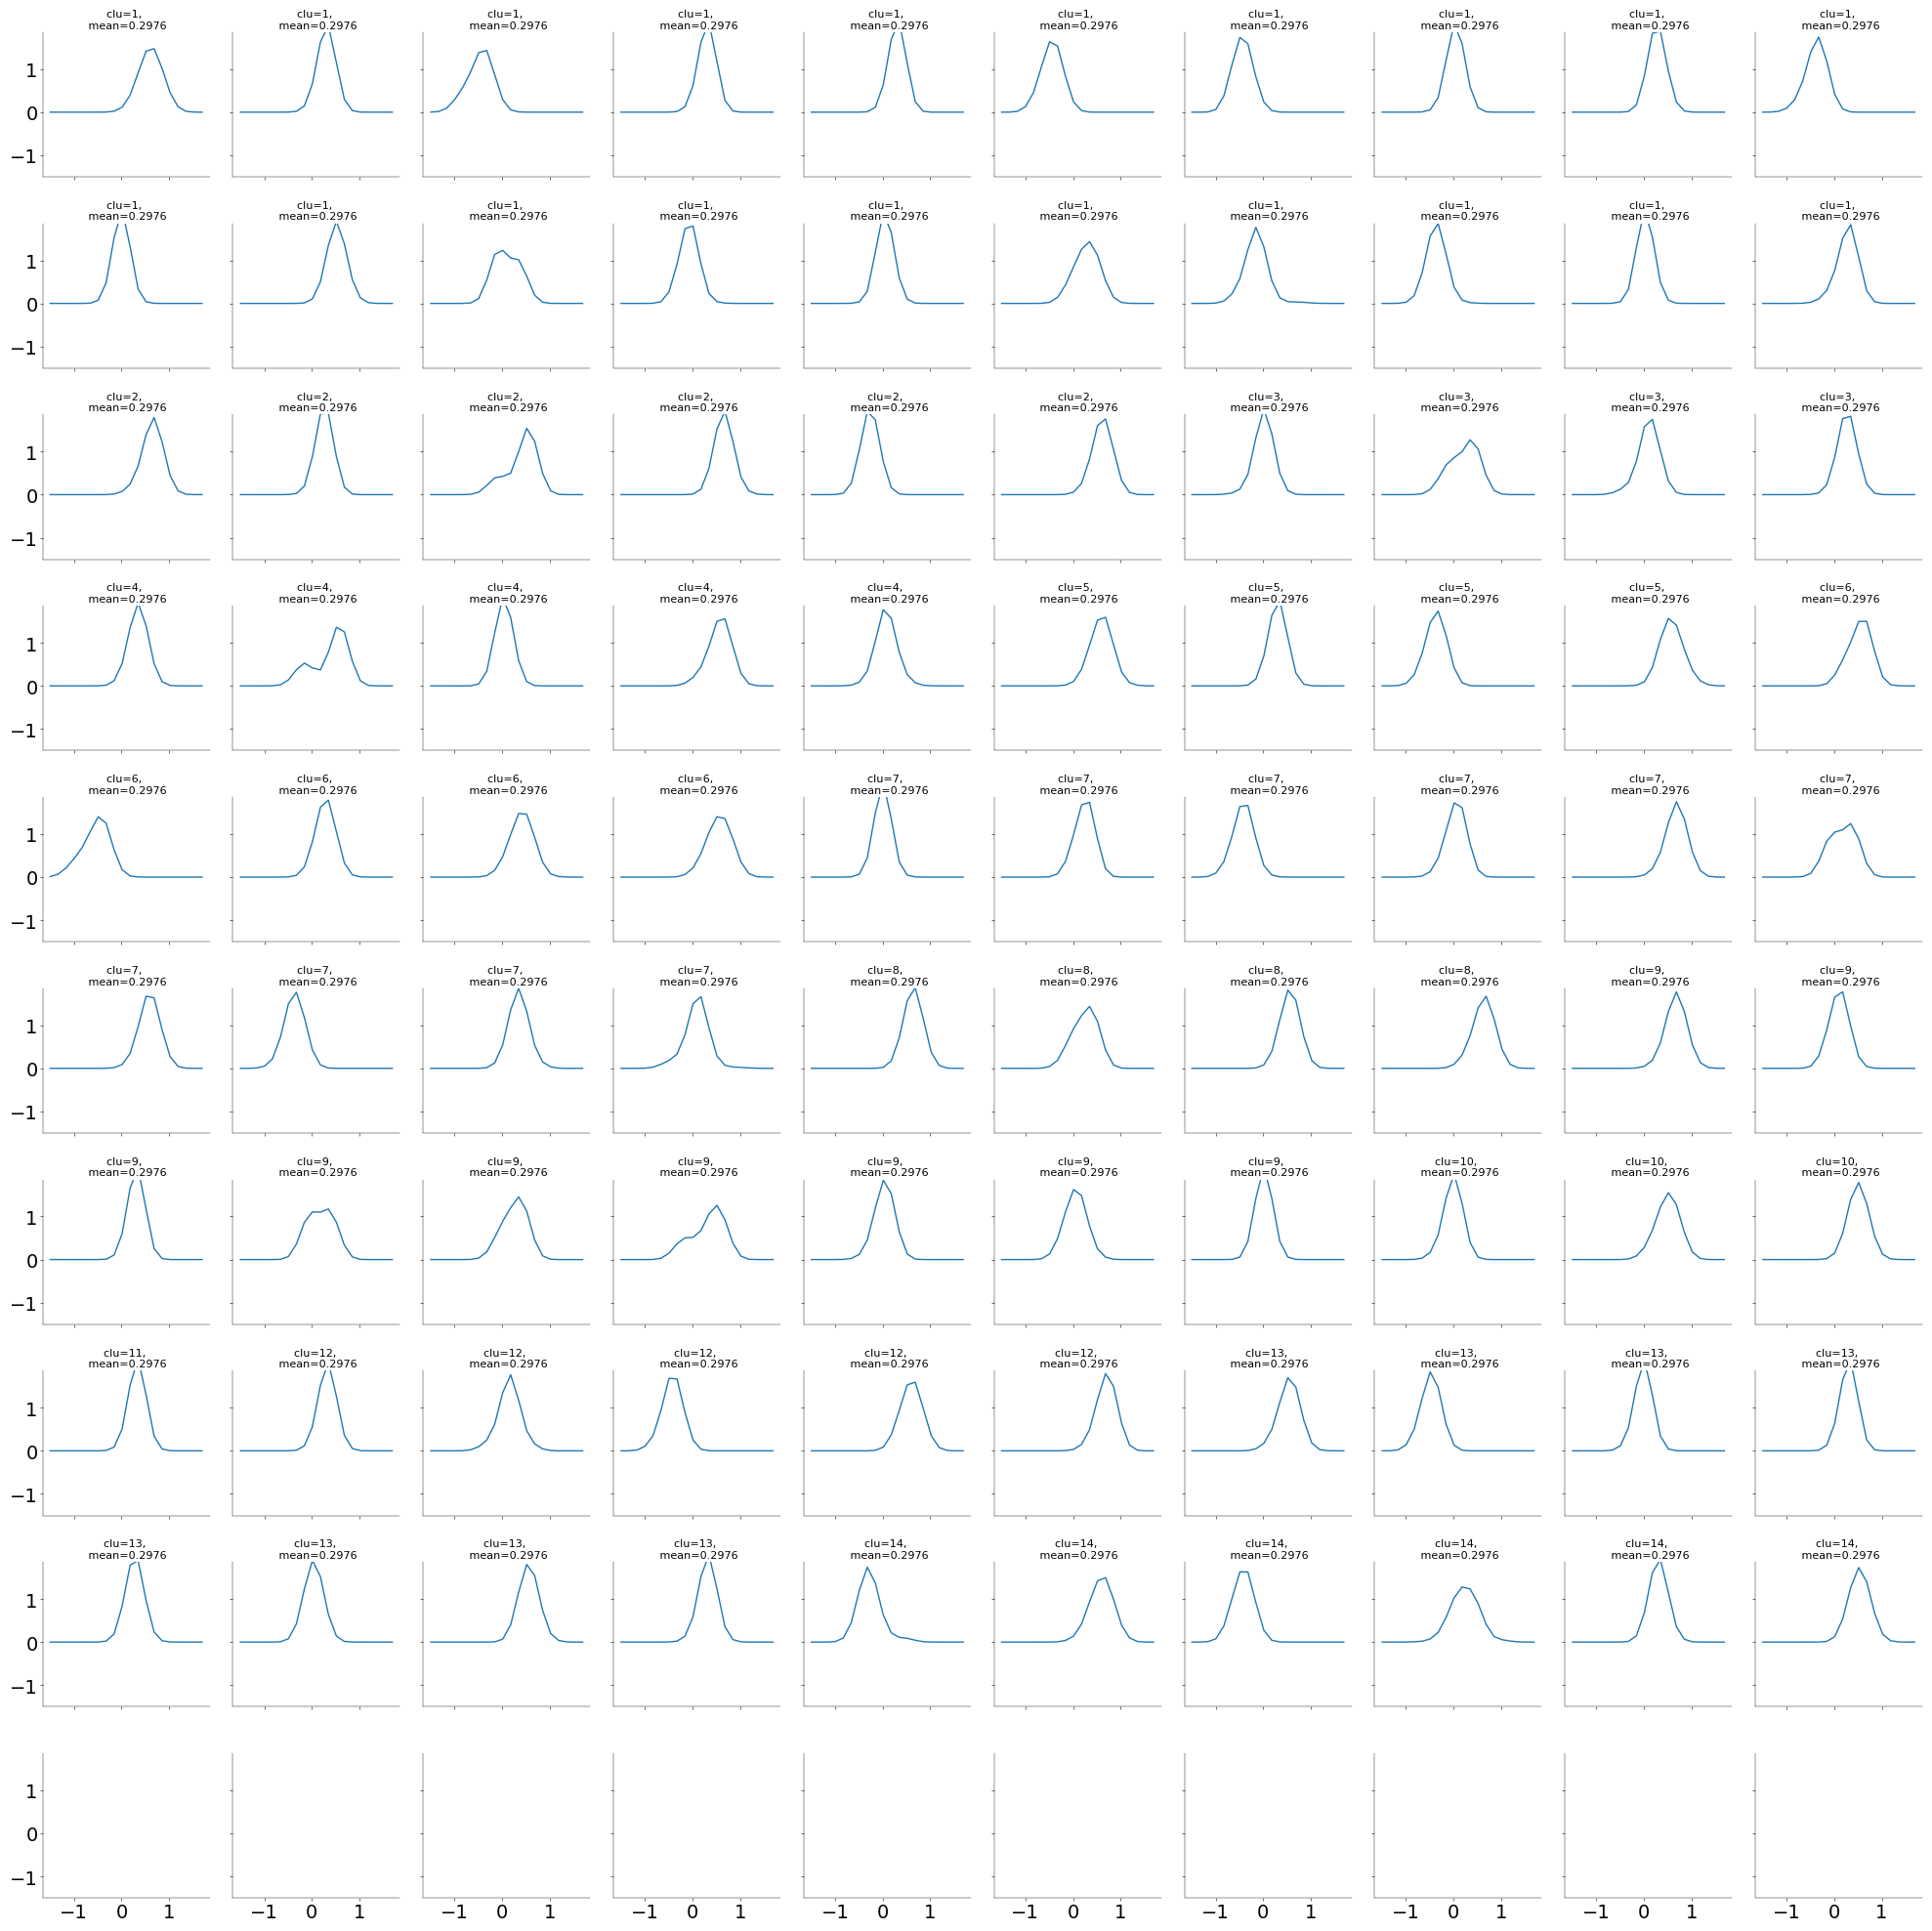

In [73]:
import math

# --------------------------------------------------------------------
# plot the Z-density maps and their means sorted by class label (1 pt)
# Note: make sure the clusters are comparable.

# plot only first 100 density maps
# density_maps_z = density_maps_z[:100]

clusters = morphometric_statistics["cluster"].tolist()[:100]
sort_idx = np.argsort(clusters)

fig, axes = plt.subplots(10, 10, figsize=(20, 20), sharex=True, sharey=True)
axes = axes.flatten()

for i, idx in enumerate(sort_idx):
    dm_z = density_maps_z[:100][idx]

    clu = clusters[idx]

    if clu is np.nan or math.isnan(clu):
        continue

    axes[i].plot(dm_z["edges"][0][:-1], dm_z["data"])
    mean = np.mean(dm_z["data"])
    axes[i].set_title(f"clu={int(clu)}, \n mean={mean:.4f}", fontsize=8)
    axes[i].set_ylim(min_z, max_z)  # similar y-scaling across plots

plt.tight_layout()
# --------------------------------------------------------------------

Note sure why all the means are the same value??

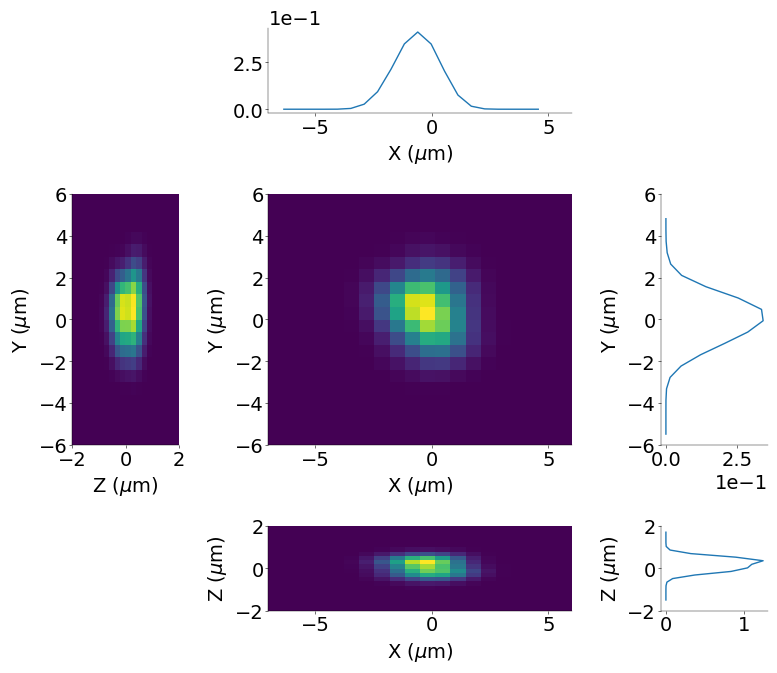

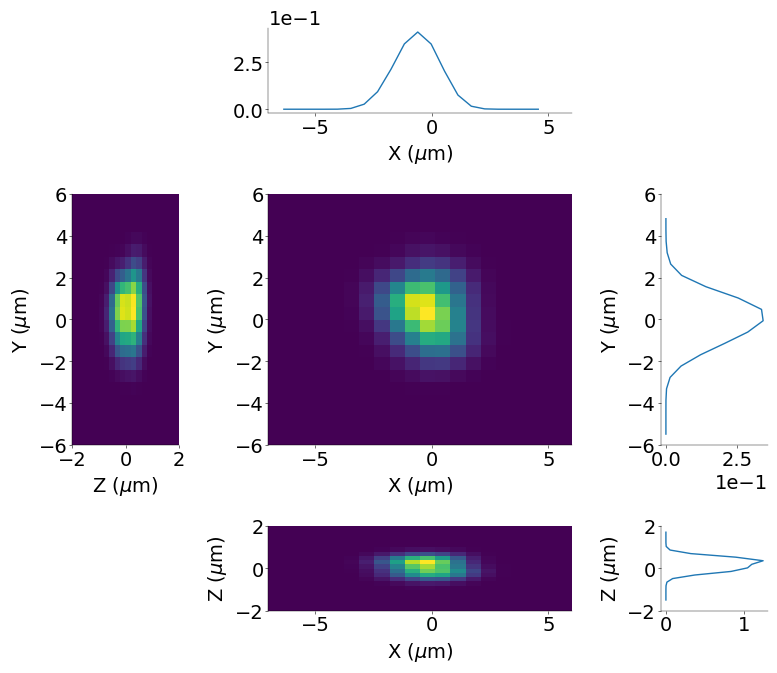

In [74]:
filename = "0060_00556_3R_C02_01.swc"  # example (comparison with 0061_00549_4R_C04_01)
filepath = data_path + filename
N = file_manager.load_swc_file(filepath, pca_rot=False, soma_center=False)
dendrites = N.get_dendritic_tree()
density_map = compute_density_maps(dendrites, config_global)
plot_density_maps(density_map)

### Questions (1 pt)

1) What does the Z-density map tell you about the cell types? Can you identify a trend in the density maps?

**Answer:**

There isn't a consistent monotonic trend.



2) Which cluster(s) would you expect the cell from Task 1 to come from and why?

**Answer:**

I am a bit confused, from looking at the image in Task 1, I would have expected a bimodal distribution in the z-plane for bistratified cells such as `0060_00556_3R_C02_01.swc`. But I don't see that here when plotting with `plot_density_maps`.

## Task 4: 2D embedding using t-SNE


Embed both data, the morphometric statistics and the density maps, in 2D using t-SNE and color each embedded point by its cluster assignment.

*Grading: 3 pts*

In [75]:
clean_density_maps_z = np.array([entry["data"] for entry in density_maps_z])

print(len(density_maps_z))
print(len(clusters))
print(clusters[:10])

550
100
[nan, 6.0, 2.0, 1.0, 7.0, 10.0, 10.0, 1.0, 8.0, 2.0]


In [76]:
from openTSNE import TSNE

# ----------------------------------------------------------------------
# Fit t-SNE with morphometric statistics and density maps (0.5 + 0.5 pt)
# Note that this can take a bit to run. (use perplexity=100
# and a random state of 17)
# ----------------------------------------------------------------------

tsne_morph = TSNE(n_components=2, perplexity=100, learning_rate=200, random_state=17)
X_tsne_morph = tsne_morph.fit(morphometric_data)

tsne_density = TSNE(n_components=2, perplexity=100, learning_rate=200, random_state=17)
X_tsne_density = tsne_density.fit(clean_density_maps_z)

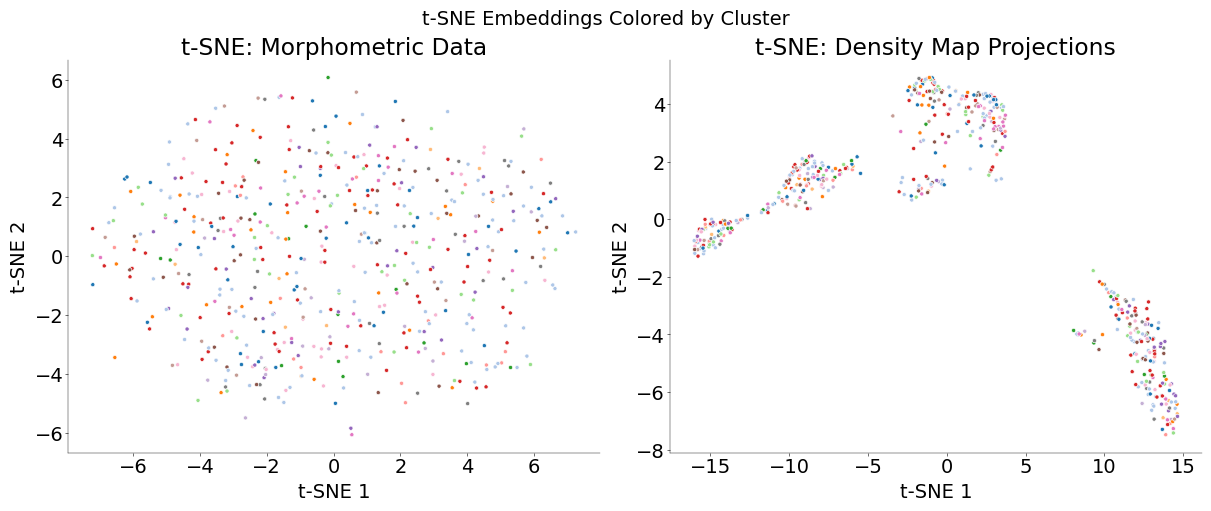

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")

# ----------------------------------------------------------------------------
# plot tsne fits for both morpometric statistics and z-projected density maps.
# Color the points appropriately and answer the questions below. (2 pt)
# ----------------------------------------------------------------------------

clusters = morphometric_statistics["cluster"].values
clusters = np.nan_to_num(clusters, nan=-1)


sns.scatterplot(
    x=X_tsne_morph[:, 0],
    y=X_tsne_morph[:, 1],
    hue=clusters,
    ax=axes[0],
    palette="tab20",
    legend=None,
)


axes[0].set_title("t-SNE: Morphometric Data")
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")


sns.scatterplot(
    x=X_tsne_density[:, 0],
    y=X_tsne_density[:, 1],
    hue=clusters,
    ax=axes[1],
    palette="tab20",
    legend=None,
)



axes[1].set_title("t-SNE: Density Map Projections")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

plt.suptitle("t-SNE Embeddings Colored by Cluster", fontsize=14)
plt.show()

### Questions:
1) Which representation produces the better clustering? Why could this be the case?

**Answer:**

The density map representation on the right clusters the data clearly better. While the tSNE density map projections show very clear, distinguished groups, the tSNE projection of the morphometric data appear diffuse and almost uniformly spread across the 2D space. 

This could be explained by the fact that morphometric statistics are handcrafted features that try to summarize aspects of a neurons morphology with single numbers. This might not capture the right differences between the neurons of different clusters or many clusters might share similar values for morphometric features. The tSNE embedding tries to preserve local similarities and therefore might fail to detect the clusters correctly. 
The tSNE embedding of the density map, however, shows clearer clustering because it captures the actual spatial layout of dendrites. In our case: many retinal neuron types differ in the way their dendrites are layered vertically, and the z-projection density map shows this. The tSNE is then able to group neurons with similar z-structure together, as it tries to preserve local similarities. 

2) What are the advantages of morphometric statistics over density maps?

**Answer:**

Morphometric statistics capture interpretable features and lead to a small number of dimensions, which is useful for classical Machine Learning models. They are also compact and computationally efficient. 

3) What are the advantages of density maps over morphometric statistics?

**Answer:**

Density maps capture the true shape and spatial layout of the dendrites. As explained in the first question, they are better at preserving the local structure of neurons in a way that is actually meaningful in a biological context. This makes them particularly useful for clustering and visualization. 

## Task 5: Predicting the projection site

The relationship between neuronal morphology and functional specialization is well-established in neurobiology. Hence, we expect distinct functional domains within the thalamus to exhibit corresponding morphological signatures. In this analysis, we aim to predict the thalamic projection site (`labels['projection_site']`) of individual neurons based on their morphological characteristics. Fit a logistic regression on both morphological representations and report its average cross validated (cv=5) prediction accuracy for each. Which representation works better to recover the prediction target? Which features are most relevant for that prediction?

You can use `LogisticRegressionCV` of the scikit-learn library directly. To understand the relevance of individual features plot the fitted linear coefficients. Note, since the classes are imbalanced make sure to report the balanced prediction accuracy.

*Grading: 2 pts*

In [87]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.metrics import balanced_accuracy_score

# -----------------------------------------------------------------------------
# Fit a logistic regressor to predict the projection site based on both feature
# representations and print the avg. prediction accuracy (1 pt)
# -----------------------------------------------------------------------------

# get projection site labels
y = labels.loc[labels["cluster"].notna(), "projection_site"].values
y_encoded = LabelEncoder().fit_transform(y)

# fit and evaluate logistic regression
# for morphometric data
lr_morph = LogisticRegressionCV(cv=5, max_iter=1000)
lr_morph.fit(morphometric_data, y_encoded)
score_morph = cross_val_score(
    lr_morph, morphometric_data, y_encoded, cv=5, scoring="balanced_accuracy"
)
print("Average Prediction Accuracy for Morphometric Data: ", np.mean(score_morph))

# for morphometric data
lr_density = LogisticRegressionCV(cv=5, max_iter=1000)
lr_density.fit(clean_density_maps_z, y_encoded)
score_density = cross_val_score(
    lr_density, clean_density_maps_z, y_encoded, cv=5, scoring="balanced_accuracy"
)
print("Average Prediction Accuracy for Density Map: ", np.mean(score_density))

Average Prediction Accuracy for Morphometric Data:  0.6607684568952173
Average Prediction Accuracy for Density Map:  0.5943269875664242


While Z density maps allow for better recovery of cell type labels, they are worse than morphometric statistics on predicting the projection target. 

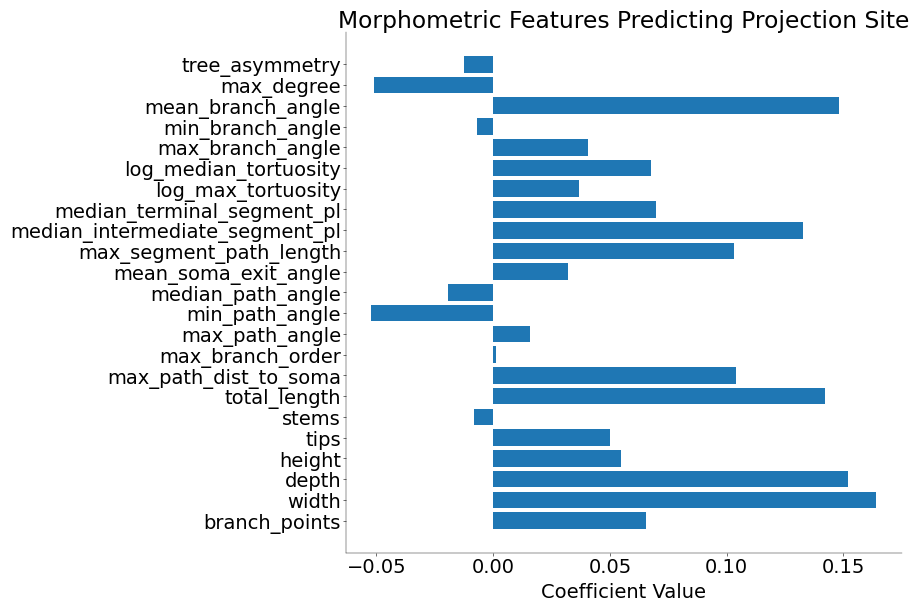

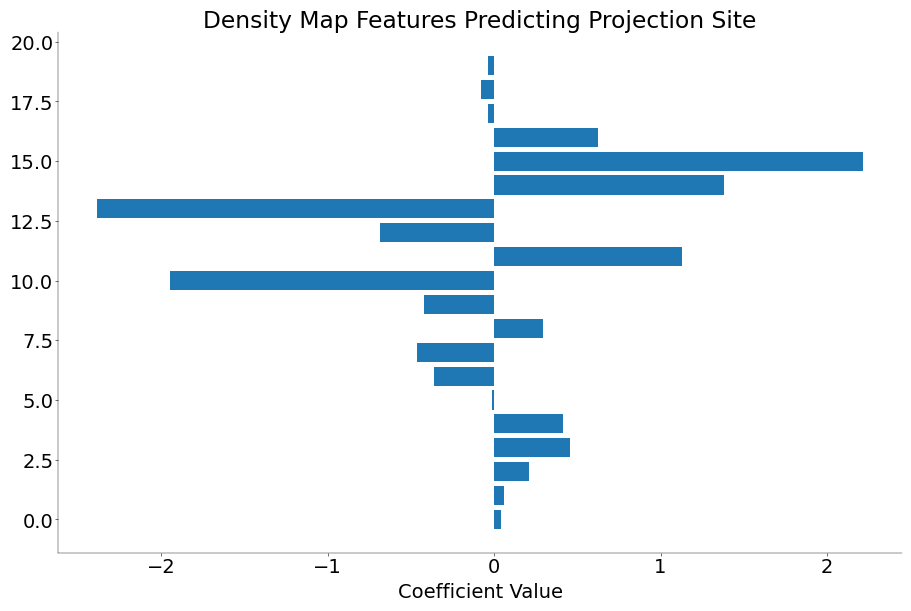

In [106]:
# ---------------------------------------------------------------------------
# Plot the fitted linear coefficients for both of the feature representations
# and answer the question below. (1 pt)
# ---------------------------------------------------------------------------

feature_names = morphometric_statistics.drop(features_to_drop, axis=1).columns

plt.figure(figsize=(9, 6))
plt.barh(feature_names, lr_morph.coef_[0])
plt.xlabel("Coefficient Value")
plt.title("Morphometric Features Predicting Projection Site")
plt.show()

plt.figure(figsize=(9, 6))
plt.barh(range(len(clean_density_maps_z[0])), lr_density.coef_[0])
plt.xlabel("Coefficient Value")
plt.title("Density Map Features Predicting Projection Site")
plt.show()

### Question:

1) Which morphometrics are informative on the projection site?

**Answer:**

To find the morphometrics that are most informative, we have to look for those with the largest positive / negative coefficients. In our case, the coefficients are all relatively small, indicating that there is not one feature that is strongly predictive of the projection site. It is likely, that the classifier builds the prediction on many small contributions, not just on a few dominant features. This makes sense, as logistic regression applies L2 regularization by default, which penalizes large coefficients. 
That being said, the morphometrics that are most informative on the projection site are (given the absolute magnitude of their coefficients)  
- mean_branch_angle
- median_intermediate_segment_pl
- total_length
- depth
- width

While these features have only small effect individually, they contribute together to differentiating projection sites. 

## Further references

Other ways to represent and compare morphologies are
* Persistence: [Description](https://link.springer.com/article/10.1007/s12021-017-9341-1) and [application on somatosensory pyramidal cell dendrites](https://academic.oup.com/cercor/article/29/4/1719/5304727) by Kanari et al. 2018

* Tree edit distance: [Heumann et al. 2009](https://link.springer.com/article/10.1007/s12021-009-9051-4)

* Sequential encoding inspired by BLAST: [Encoding](https://link.springer.com/article/10.1186/s12859-015-0604-2) and [similarity analysis on cortical dendrites](https://link.springer.com/article/10.1186/s12859-015-0605-1) by Gilette et al. 2015

* Vector point clouds: [BlastNeuron: Wan et al. 2015](https://link.springer.com/article/10.1007/s12021-015-9272-7)